In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [28]:
jupyterlab server extension list

SyntaxError: invalid syntax (2592298561.py, line 1)

In [3]:
user_events = pd.read_csv(r'C:\Users\27678\Downloads\user_events.csv')
user_events.head(10)

,event_id,user_id,event_type,event_date,product_id,amount,traffic_source
0,8490,5024,page_view,2025-12-30 04:58:24.517006,205,NaN,social
1,2296,1713,page_view,2025-12-30 05:10:26.276377,201,NaN,organic
2,3896,2558,page_view,2025-12-30 05:11:09.001887,404,NaN,organic
3,2297,1713,add_to_cart,2025-12-30 05:13:26.276377,201,NaN,organic
4,2298,1713,checkout_start,2025-12-30 05:16:26.276377,201,NaN,organic
5,8438,4993,page_view,2025-12-30 05:20:55.416929,205,NaN,organic
6,2299,1713,payment_info,2025-12-30 05:23:26.276377,201,NaN,organic
7,2300,1713,purchase,2025-12-30 05:25:26.276377,201,48.3,organic
8,8649,5102,page_view,2025-12-30 05:25:27.600119,102,NaN,organic
9,3897,2558,add_to_cart,2025-12-30 05:29:09.001887,404,NaN,organic


In [4]:
user_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 9381 entries, 0 to 9380
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   event_id        9381 non-null   int64  
 1   user_id         9381 non-null   int64  
 2   event_type      9381 non-null   str    
 3   event_date      9381 non-null   str    
 4   product_id      9381 non-null   int64  
 5   amount          826 non-null    float64
 6   traffic_source  9381 non-null   str    
dtypes: float64(1), int64(3), str(3)
memory usage: 513.2 KB


In [5]:
user_events.event_date.describe()

count                           9381
unique                          9381
top       2025-12-30 04:58:24.517006
freq                               1
Name: event_date, dtype: object

<h3>Checking nulls, column datatypes<h3>

In [6]:
user_events.dtypes

event_id            int64
user_id             int64
event_type            str
event_date            str
product_id          int64
amount            float64
traffic_source        str
dtype: object


## Change the data type of the event_date column to datetime

In [7]:
user_events['event_date'] = pd.to_datetime(user_events['event_date'])

In [8]:
## verify data type has changed
user_events.dtypes

event_id                   int64
user_id                    int64
event_type                   str
event_date        datetime64[us]
product_id                 int64
amount                   float64
traffic_source               str
dtype: object

In [9]:
user_events.isnull().sum()

event_id             0
user_id              0
event_type           0
event_date           0
product_id           0
amount            8555
traffic_source       0
dtype: int64

## Calculating KPIs and metrics

### How many purchases were made

In [10]:
purchases = len(user_events[user_events['event_type']=='purchase'])

In [11]:
purchases

826

### What was the total revenue generated

In [12]:
total_revenue = user_events['amount'].sum()

In [13]:
total_revenue


np.float64(87975.11)

<h3>What was the AOV<h3>

In [14]:
## Average Order Value = Revenue/purchases
average_order_value = round((total_revenue/purchases), 2)

In [15]:
average_order_value

np.float64(106.51)

<h3>Which traffic source generates the most revenue?<h3>

In [16]:
revenue_by_source = (
    user_events[user_events['event_type'] == 'purchase']
    .groupby('traffic_source')['amount']
    .sum()
    .round(2)
    .sort_values(ascending=False))

In [17]:
revenue_by_source

traffic_source
organic     37279.98
paid_ads    21487.54
email       17876.75
social      11330.84
Name: amount, dtype: float64

In [18]:
revenue_pct = (revenue_by_source / total_revenue * 100).round(2)
result = pd.DataFrame({
    'Revenue': revenue_by_source,
    'Percentage': revenue_pct})

In [19]:
result

,Revenue,Percentage
traffic_source,,
organic,37279.98,42.38
paid_ads,21487.54,24.42
email,17876.75,20.32
social,11330.84,12.88


<BarContainer object of 4 artists>

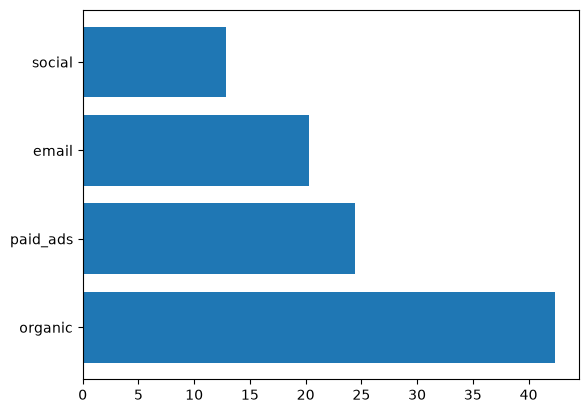

In [20]:
traffic_source = np.array(["organic", "paid_ads", "email", "social"])
Percentage = np.array([42.38, 24.42, 20.32, 12.88])
plt.barh(traffic_source, Percentage)

<h1>Product Perfomance Analysis<h1>
Which products receive the most views?
Which products are added to cart most frequently?
Which products generate the most revenue

<h3>Revenue by product <h3>

In [21]:
revenue_by_product = (
    user_events[user_events['event_type'] == 'purchase']
    .groupby('product_id')['amount']
    .sum()
    .round(2)
    .sort_values(ascending=False))

In [22]:
revenue_by_product

product_id
205    15905.07
404    15377.31
101    14688.18
305    14622.48
201    13925.94
102    13456.13
Name: amount, dtype: float64

<h3>Visulising Revenue by Product<h3>

In [23]:
product_id = np.array(["205", "404", "101", "305", "201", "102"])
product_revenue = np.array([15905.07, 15377.31, 14688.18, 14622.48, 13925.94, 13456.13])

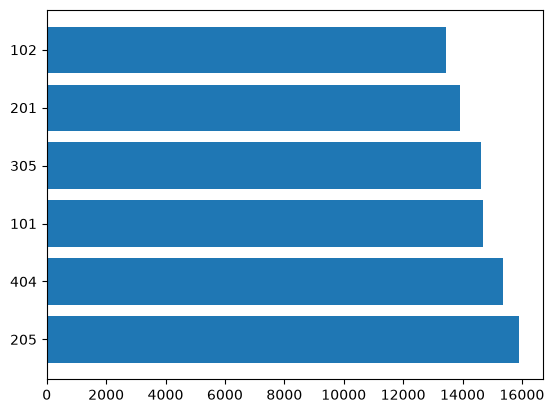

In [24]:
fig = plt.barh(product_id, product_revenue)

In [25]:
most_viewed_product = (
    user_events[user_events['event_type'] == 'page_view']
    .groupby('product_id')['event_type']
    .count()
    .sort_values(ascending=False))

In [26]:
most_viewed_products

NameError: name 'most_viewed_products' is not defined

<h3>Revenue trend<h3>

In [ ]:
purchases = user_events[
    user_events['event_type'] == 'purchase'
].copy()

In [ ]:
##Adds day column
purchases["day"] = user_events["event_date"].dt.to_period("D")

In [ ]:
purchases

In [ ]:
monthly_revenue = purchases.groupby('day')['amount'].sum().reset_index()

In [ ]:
monthly_revenue.head()

In [ ]:
# Convert Period to Timestamp
#monthly_revenue['day'] = monthly_revenue['day'].dt.to_timestamp()

# Plot
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue['day'],
    monthly_revenue['amount'],
    marker='o'
)

plt.title('Daily Revenue Trend')
plt.xlabel('day')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.grid(True)

<h2>Calculating conversion rates<h2>

<h3>Count the number of events at each stage<h3>

In [ ]:
page_views = len(user_events[user_events["event_type"] == "page_view"])
add_to_cart = len(user_events[user_events["event_type"] == "add_to_cart"])
checkout_start = len(user_events[user_events["event_type"] == "checkout_start"])
payment_info = len(user_events[user_events["event_type"] == "payment_info"])
purchases = len(user_events[user_events['event_type']=='purchase'])


In [ ]:
## Calculating conversion rate percentages

<h3>Create Funnel summary table<h3>

In [ ]:
funnel_df = pd.DataFrame({
    "stage" : ["Page_view",
              "Add_to_cart",
              "Checkout_start",
              "Payment_info",
              "Purchases"],

    "Count" : [page_views,
              add_to_cart,
              checkout_start,
              payment_info,
              purchases]
})

In [ ]:
funnel_df

<h3>Visualise the funnel<h>

In [ ]:
fig = px.funnel(
    funnel_df,
    x='Count',
    y='stage',
    title='Customer Conversion Funnel'
)


In [ ]:
fig.update_layout(
    title_x=0.5,
    font=dict(
        size=10
    ),
    width=900,
    height=400,
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)"
)
 

In [ ]:
fig.show()

In [ ]:
## Where are users dropping off?
## What percentage of users become buyers -- overall conversion rate
## Cart abandonment rate